In [1]:
import os
import re
import copy
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as transforms
import torchvision.models as models

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Khai báo đường dẫn
BASE_DIR = '/content/drive/MyDrive/VQA_MonAnVietNam'
DATA_DIR = os.path.join(BASE_DIR, 'data')
IMG_DIR = os.path.join(DATA_DIR, 'images')
CSV_PATH = os.path.join(DATA_DIR, 'vqa_dataset.csv')
WEIGHTS_DIR = os.path.join(BASE_DIR, 'weights')

# Tạo thư mục lưu trọng số nếu chưa có
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Cấu hình thiết bị (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Mounted at /content/drive
Đang sử dụng thiết bị: cpu


In [2]:
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.idx = 4

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer(text):
        text = str(text).lower()
        # Giữ lại chữ cái, số và loại bỏ dấu câu đặc biệt
        text = re.sub(r'[^\w\s]', '', text)
        return text.split()

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        for sentence in sentence_list:
            for word in self.tokenizer(sentence):
                frequencies[word] += 1

        for word, count in frequencies.items():
            if count >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer(text)
        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

print("Đang đọc dữ liệu và xây dựng Vocabulary...")
df = pd.read_csv(CSV_PATH)

# Gom tất cả câu hỏi và câu trả lời để tạo bộ từ vựng
all_text = df['question'].tolist() + df['answer'].tolist()
vocab = Vocabulary(freq_threshold=2)
vocab.build_vocabulary(all_text)

print(f"Kích thước từ vựng: {len(vocab)} từ.")

Đang đọc dữ liệu và xây dựng Vocabulary...
Kích thước từ vựng: 693 từ.


In [3]:
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch
from torch.nn.utils.rnn import pad_sequence
import os
from PIL import Image
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

def collate_fn_phobert_transformer(batch):
    images, input_ids, attention_masks, answers = zip(*batch)
    images = torch.stack(images, 0)
    input_ids = torch.stack(input_ids, 0)
    attention_masks = torch.stack(attention_masks, 0)
    answers_padded = pad_sequence(answers, batch_first=True, padding_value=0)
    return images, input_ids, attention_masks, answers_padded

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class VQA_A2_ViT_PhoBERT_Dataset(Dataset):
    def __init__(self, df, img_dir, tokenizer, vocab, transform=None, max_len=50):
        self.df = df
        self.img_dir = img_dir
        self.tokenizer = tokenizer
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_name = row['image_path'].split('images/')[-1] if row['image_path'].startswith('images/') else row['image_path']
        img_path = os.path.join(self.img_dir, img_name)

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        encoded_q = self.tokenizer(
            row['question'],
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )

        input_ids = encoded_q['input_ids'].squeeze(0)
        attention_mask = encoded_q['attention_mask'].squeeze(0)

        ans_tokens = [self.vocab.stoi["<SOS>"]] + self.vocab.numericalize(row['answer']) + [self.vocab.stoi["<EOS>"]]
        answer_tensor = torch.tensor(ans_tokens)

        return image, input_ids, attention_mask, answer_tensor

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = VQA_A2_ViT_PhoBERT_Dataset(train_df, IMG_DIR, tokenizer, vocab, transform=train_transform)
val_dataset = VQA_A2_ViT_PhoBERT_Dataset(val_df, IMG_DIR, tokenizer, vocab, transform=val_transform)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_phobert_transformer, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_phobert_transformer, num_workers=0)

print(f"Tổng mẫu Train: {len(train_dataset)}")
print(f"Tổng mẫu Val: {len(val_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tổng mẫu Train: 5042
Tổng mẫu Val: 1261


In [4]:
import torch
import torch.nn as nn
import math
from transformers import AutoModel

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class VQA_A2_Transformer_Model(nn.Module):
    def __init__(self, vocab_size, embed_size=768, nhead=8, num_layers=4, dropout_rate=0.1):
        super(VQA_A2_Transformer_Model, self).__init__()

        self.vit = AutoModel.from_pretrained("google/vit-base-patch16-224-in21k")
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base")

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.pos_encoder = PositionalEncoding(embed_size)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_size,
            nhead=nhead,
            dim_feedforward=embed_size * 4,
            dropout=dropout_rate,
            batch_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.vocab_classifier = nn.Linear(embed_size, vocab_size)
        self.dropout = nn.Dropout(dropout_rate)

    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, images, input_ids, attention_mask, answers=None):
        with torch.no_grad():
            img_features = self.vit(pixel_values=images).last_hidden_state[:, 1:, :]
            text_features = self.phobert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state

        memory = torch.cat([img_features, text_features], dim=1)

        if answers is not None:
            tgt_embed = self.embedding(answers)
            tgt_embed = self.pos_encoder(tgt_embed)

            tgt_mask = self.generate_square_subsequent_mask(answers.size(1)).to(images.device)

            output = self.transformer_decoder(
                tgt=tgt_embed,
                memory=memory,
                tgt_mask=tgt_mask
            )
            return self.vocab_classifier(self.dropout(output))
        else:
            return memory

EMBED_SIZE = 768
NHEAD = 8
NUM_LAYERS = 4

model = VQA_A2_Transformer_Model(
    vocab_size=len(vocab),
    embed_size=EMBED_SIZE,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dropout_rate=0.1
).to(device)

print(f"Đã khởi tạo Mô hình A2 (ViT + PhoBERT + Transformer Decoder).")

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Đã khởi tạo Mô hình A2 (ViT + PhoBERT + Transformer Decoder).


In [5]:
import copy
import torch.optim as optim
import torch.nn.functional as F
import os
import torch
from transformers import get_cosine_schedule_with_warmup
from tqdm.auto import tqdm

def label_smoothed_nll_loss(logits, targets, epsilon=0.1, ignore_index=0):
    log_probs = F.log_softmax(logits, dim=-1)
    mask = (targets != ignore_index)
    nll_loss = F.nll_loss(log_probs, targets, ignore_index=ignore_index, reduction='sum')
    smooth_loss = -log_probs.sum(dim=-1)[mask].sum()
    num_valid_tokens = mask.sum().item()
    if num_valid_tokens == 0: return nll_loss * 0.0
    vocab_size = log_probs.size(-1)
    loss = (1.0 - epsilon) * nll_loss + (epsilon / vocab_size) * smooth_loss
    return loss / num_valid_tokens

EPOCHS = 30
best_val_loss = float('inf')
MODEL_SAVE_PATH = os.path.join(WEIGHTS_DIR, 'vqa_model_A2_vit_phobert_transformer.pth')

optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
total_steps = len(train_loader) * EPOCHS
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

history_train_loss = []
history_val_loss = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 15)

    model.train()
    train_loss = 0.0
    for images, input_ids, attention_mask, answers in tqdm(train_loader, desc="Training"):
        images, input_ids, attention_mask, answers = images.to(device), input_ids.to(device), attention_mask.to(device), answers.to(device)

        optimizer.zero_grad()

        outputs = model(images, input_ids, attention_mask, answers[:, :-1])
        logits = outputs.reshape(-1, outputs.shape[-1])
        targets = answers[:, 1:].reshape(-1)

        loss = label_smoothed_nll_loss(logits, targets, epsilon=0.1, ignore_index=vocab.stoi["<PAD>"])

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()
        train_loss += loss.item() * images.size(0)

    epoch_train_loss = train_loss / len(train_dataset)
    history_train_loss.append(epoch_train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, input_ids, attention_mask, answers in tqdm(val_loader, desc="Validation"):
            images, input_ids, attention_mask, answers = images.to(device), input_ids.to(device), attention_mask.to(device), answers.to(device)

            outputs = model(images, input_ids, attention_mask, answers[:, :-1])
            logits = outputs.reshape(-1, outputs.shape[-1])
            targets = answers[:, 1:].reshape(-1)

            loss = label_smoothed_nll_loss(logits, targets, epsilon=0.1, ignore_index=vocab.stoi["<PAD>"])
            val_loss += loss.item() * images.size(0)

    epoch_val_loss = val_loss / len(val_dataset)
    history_val_loss.append(epoch_val_loss)

    current_lr = scheduler.get_last_lr()[0]
    print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | LR: {current_lr:.6f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("Đã lưu trọng số Transformer tốt nhất.")

print("\nHOÀN TẤT HUẤN LUYỆN MÔ HÌNH A2!")


Epoch 1/30
---------------


Training:   0%|          | 0/316 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 5.4925 | Val Loss: 4.5952 | LR: 0.000007
Đã lưu trọng số Transformer tốt nhất.

Epoch 2/30
---------------


Training:   0%|          | 0/316 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 1.8966 | Val Loss: 2.4004 | LR: 0.000000

Epoch 30/30
---------------


Training:   0%|          | 0/316 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 1.8929 | Val Loss: 2.4003 | LR: 0.000000

HOÀN TẤT HUẤN LUYỆN MÔ HÌNH A2!


Đã lưu biểu đồ A2 vào: /content/drive/MyDrive/VQA_MonAnVietNam/weights/loss_plot_A2_vit_phobert_transformer.png


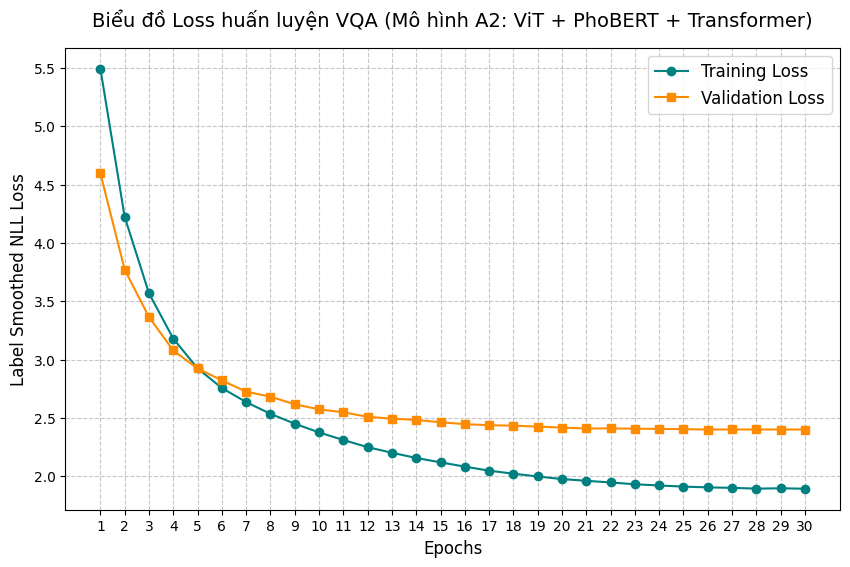

In [6]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))

epochs_run = len(history_train_loss)

plt.plot(range(1, epochs_run + 1), history_train_loss, label='Training Loss', color='teal', marker='o')
plt.plot(range(1, epochs_run + 1), history_val_loss, label='Validation Loss', color='darkorange', marker='s')

plt.title('Biểu đồ Loss huấn luyện VQA (Mô hình A2: ViT + PhoBERT + Transformer)', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Label Smoothed NLL Loss', fontsize=12)
plt.xticks(range(1, epochs_run + 1))
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

PLOT_SAVE_PATH = os.path.join(WEIGHTS_DIR, 'loss_plot_A2_vit_phobert_transformer.png')
plt.savefig(PLOT_SAVE_PATH, dpi=300, bbox_inches='tight')
print(f"Đã lưu biểu đồ A2 vào: {PLOT_SAVE_PATH}")

plt.show()

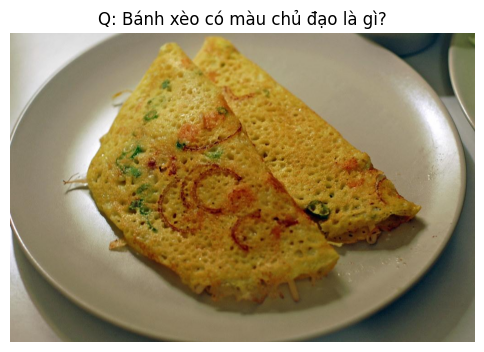

AI Trả lời: màu vàng
Đáp án đúng gốc: Màu vàng nhạt.


In [24]:
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
import os
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

def predict_a2_transformer(image_path, question_text, model, vocab, device, max_len=15):
    A2_MODEL_PATH = os.path.join(WEIGHTS_DIR, 'vqa_model_A2_vit_phobert_transformer.pth')

    if os.path.exists(A2_MODEL_PATH):
        model.load_state_dict(torch.load(A2_MODEL_PATH, map_location=device))
        model.eval()
    else:
        print(f"Lỗi: Không tìm thấy file tại {A2_MODEL_PATH}")
        return

    image = Image.open(image_path).convert("RGB")
    img_tensor = val_transform(image).unsqueeze(0).to(device)

    encoded_q = tokenizer(question_text, return_tensors='pt', truncation=True, max_length=50)
    input_ids = encoded_q['input_ids'].to(device)
    attention_mask = encoded_q['attention_mask'].to(device)

    predicted_words = []

    with torch.no_grad():
        memory = model(img_tensor, input_ids, attention_mask, answers=None)

        current_tokens = [vocab.stoi["<SOS>"]]

        for _ in range(max_len):
            tgt_tensor = torch.tensor(current_tokens).unsqueeze(0).to(device)

            tgt_embed = model.embedding(tgt_tensor)
            tgt_embed = model.pos_encoder(tgt_embed)

            tgt_mask = model.generate_square_subsequent_mask(tgt_tensor.size(1)).to(device)

            output = model.transformer_decoder(
                tgt=tgt_embed,
                memory=memory,
                tgt_mask=tgt_mask
            )

            logits = model.vocab_classifier(output)
            next_token_logits = logits[0, -1, :]
            _, next_token = torch.max(next_token_logits, dim=0)

            word = vocab.itos[next_token.item()]

            if word == "<EOS>":
                break

            predicted_words.append(word)
            current_tokens.append(next_token.item())

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"Q: {question_text}")
    plt.axis('off')
    plt.show()

    print(f"AI Trả lời: {' '.join(predicted_words)}")
    return predicted_words

test_row = df.sample(1).iloc[0]
img_name = test_row['image_path'].split('images/')[-1] if test_row['image_path'].startswith('images/') else test_row['image_path']
test_img_path = os.path.join(IMG_DIR, img_name)

pred = predict_a2_transformer(test_img_path, test_row['question'], model, vocab, device)
print(f"Đáp án đúng gốc: {test_row['answer']}")

⏳ Đang khởi tạo mô hình A2 và nạp trọng số...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Đã nạp thành công trọng số A2.
  🖼️  DEMO VQA A2: ViT + PhoBERT + Transformer Decoder

📂 Tải lên ảnh để bắt đầu:


Saving cach-lam-banh-khot-1_06187869db3b4e878857e0587f3a1c09.jpg to cach-lam-banh-khot-1_06187869db3b4e878857e0587f3a1c09 (1).jpg


/tmp/ipykernel_4478/3921074760.py:24: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


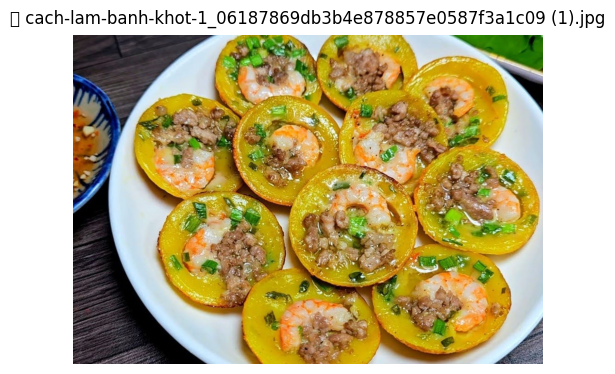


❓ Câu hỏi (new = ảnh mới | thoat = thoát): đây là món ăn gì
────────────────────────────────────────────────────────────
  🤖  bánh bèo
────────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): bánh được đặt ở đâu
────────────────────────────────────────────────────────────
  🤖  bánh được đặt trên một chiếc đĩa
────────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): thành phần trên bánh có gì
────────────────────────────────────────────────────────────
  🤖  tôm tươi và hành lá
────────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): đĩa có màu gì
────────────────────────────────────────────────────────────
  🤖  đĩa có màu xanh lá cây
────────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): có tôm không
────────────────────────────────────────────────────────────
  🤖  có tôm
───────────────────────

Saving Screenshot 2026-04-24 092549.png to Screenshot 2026-04-24 092549.png


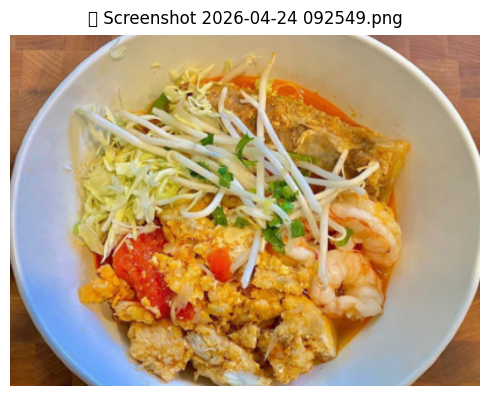


❓ Câu hỏi (new = ảnh mới | thoat = thoát): đây là món ăn gì
────────────────────────────────────────────────────────────
  🤖  bún riêu
────────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): nước dùng có màu gì
────────────────────────────────────────────────────────────
  🤖  màu cam đỏ
────────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): món ăn được đặt ở đâu
────────────────────────────────────────────────────────────
  🤖  món ăn được đặt trên bàn gỗ
────────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): món này ăn có cay không
────────────────────────────────────────────────────────────
  🤖  mì quảng
────────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): thoat


In [6]:
# ============================================================
# 🔍 CELL SUY LUẬN (INFERENCE) HOÀN CHỈNH - MÔ HÌNH A2
# Tích hợp: Diverse Beam Search + Giao diện hỏi đáp
# ============================================================

import os
import io
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from transformers import AutoTokenizer

# ── 0. HÀM HỖ TRỢ HIỂN THỊ (Sửa lỗi NameError) ─────────────────────────────
def show_image(image_pil, title=""):
    """Hiển thị ảnh bằng matplotlib."""
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image_pil)
    if title:
        ax.set_title(title, fontsize=12, pad=8)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# ── 1. KHỞI TẠO MÔ HÌNH VÀ TẢI TRỌNG SỐ ──────────────────────────────
print("⏳ Đang khởi tạo mô hình A2 và nạp trọng số...")

# Lưu ý: Các tham số này PHẢI khớp hoàn toàn với kiến trúc model A2 của bạn
EMBED_SIZE = 768  # Kích thước embedding của ViT/PhoBERT base
NHEAD      = 8
NUM_LAYERS = 4

inference_model = VQA_A2_Transformer_Model(
    vocab_size   = len(vocab),
    embed_size   = EMBED_SIZE,
    nhead        = NHEAD,
    num_layers   = NUM_LAYERS,
    dropout_rate = 0.0
).to(device)

# Kiểm tra đường dẫn file trọng số
MODEL_SAVE_PATH = os.path.join(WEIGHTS_DIR, 'vqa_model_A2_vit_phobert_transformer.pth')

if os.path.exists(MODEL_SAVE_PATH):
    inference_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    inference_model.eval()
    print(f"✅ Đã nạp thành công trọng số A2.")
else:
    print(f"⚠️ Cảnh báo: Không tìm thấy file trọng số tại {MODEL_SAVE_PATH}")

# Tokenizer
infer_tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

# ── 2. THAM SỐ DIVERSE BEAM SEARCH ───────────────────────────────────────────
NUM_GROUPS      = 3
BEAMS_PER_GROUP = 2
MAX_LEN         = 15
LENGTH_ALPHA    = 0.7
DIVERSITY_GAMMA = 0.5

# ── 3. LOGIC GIẢI MÃ TRANSFORMER ─────────────────────────────────────────────
def transformer_step(tgt_indices, memory):
    """Thực hiện một bước giải mã qua Transformer Decoder."""
    tgt_tensor = torch.tensor(tgt_indices).unsqueeze(0).to(device)

    tgt_embed = inference_model.embedding(tgt_tensor)
    tgt_embed = inference_model.pos_encoder(tgt_embed)

    sz = tgt_tensor.size(1)
    mask = inference_model.generate_square_subsequent_mask(sz).to(device)

    # Decoder lấy thông tin từ Memory (Ảnh + Text Encoder)
    output = inference_model.transformer_decoder(
        tgt=tgt_embed,
        memory=memory,
        tgt_mask=mask
    )

    logits = inference_model.vocab_classifier(output[:, -1, :])
    return F.log_softmax(logits, dim=1)

def length_penalized_score(score, length, alpha=LENGTH_ALPHA):
    return score / (length ** alpha) if length > 0 else score

# ── 4. HÀM DỰ ĐOÁN CHÍNH ─────────────────────────────────────────────────────
def infer_vqa_a2_diverse(image_pil, question_text):
    img_tensor = val_transform(image_pil).unsqueeze(0).to(device)

    encoded_q = infer_tokenizer(
        question_text, return_tensors='pt',
        truncation=True, max_length=50, padding='max_length'
    )
    input_ids = encoded_q['input_ids'].to(device)
    attention_mask = encoded_q['attention_mask'].to(device)

    with torch.no_grad():
        # Encoder A2: Lấy Memory tổng hợp (Ảnh + Chữ)
        memory = inference_model(img_tensor, input_ids, attention_mask, answers=None)

    sos_idx = vocab.stoi["<SOS>"]
    groups = [[(0.0, [sos_idx])] for _ in range(NUM_GROUPS)]
    completed = []

    for _ in range(MAX_LEN):
        tokens_chosen_this_step = []
        for g in range(NUM_GROUPS):
            candidates = []
            for score, tokens in groups[g]:
                if tokens[-1] == vocab.stoi["<EOS>"]: continue

                log_prob = transformer_step(tokens, memory)

                # Diversity Penalty
                penalized_prob = log_prob[0].clone()
                for p_idx in tokens_chosen_this_step:
                    penalized_prob[p_idx] -= DIVERSITY_GAMMA

                topk_scores, topk_idxs = penalized_prob.topk(BEAMS_PER_GROUP)

                for lp, idx in zip(topk_scores, topk_idxs):
                    t_idx = idx.item()
                    new_score = score + log_prob[0][t_idx].item()
                    new_tokens = tokens + [t_idx]

                    if t_idx == vocab.stoi["<EOS>"]:
                        completed.append((new_score, new_tokens))
                    else:
                        candidates.append((new_score, new_tokens))
                        tokens_chosen_this_step.append(t_idx)

            if not candidates: continue
            candidates.sort(key=lambda x: length_penalized_score(x[0], len(x[1])), reverse=True)
            groups[g] = candidates[:BEAMS_PER_GROUP]

        if all(len(g) == 0 or g[0][1][-1] == vocab.stoi["<EOS>"] for g in groups): break

    for g in groups:
        for s, t in g: completed.append((s, t))

    if not completed: return "..."
    completed.sort(key=lambda x: length_penalized_score(x[0], len(x[1])), reverse=True)

    # Dịch sang tiếng Việt
    res = [vocab.itos[t] for t in completed[0][1]
           if t not in [vocab.stoi["<SOS>"], vocab.stoi["<EOS>"], vocab.stoi["<PAD>"]]]
    return " ".join(res)

# ── 5. VÒNG LẶP GIAO DIỆN ───────────────────────────────────────────────────
print("=" * 60)
print("  🖼️  DEMO VQA A2: ViT + PhoBERT + Transformer Decoder")
print("=" * 60)

current_image = None

while True:
    if current_image is None:
        print("\n📂 Tải lên ảnh để bắt đầu:")
        uploaded = files.upload()
        if not uploaded: break
        filename = list(uploaded.keys())[0]
        current_image = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")
        show_image(current_image, title=f"📷 {filename}")

    question = input("\n❓ Câu hỏi (new = ảnh mới | thoat = thoát): ").strip()
    if question.lower() in ["thoat", "exit", "quit"]: break
    if question.lower() == "new":
        current_image = None
        continue
    if question == "": continue

    answer = infer_vqa_a2_diverse(current_image, question)
    print("─" * 60)
    print(f"  🤖  {answer}")
    print("─" * 60)

In [8]:
!pip install -q bert-score transformers
!pip install -q rouge-score bert-score nltk transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [9]:
import torch
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from tqdm.auto import tqdm

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

def evaluate_vqa_metrics(model, val_dataset, vocab, device, max_len=15):
    model.eval()
    predictions_str = []
    references_str = []

    print("Đang chạy suy luận trên tập Validation với mô hình A2...")

    with torch.no_grad():
        for idx in tqdm(range(len(val_dataset)), desc="Dự đoán"):
            image, input_ids, attention_mask, answer_tensor = val_dataset[idx]

            img_tensor = image.unsqueeze(0).to(device)
            input_ids = input_ids.unsqueeze(0).to(device)
            attention_mask = attention_mask.unsqueeze(0).to(device)

            memory = model(img_tensor, input_ids, attention_mask, answers=None)

            current_tokens = [vocab.stoi["<SOS>"]]
            pred_words = []

            for _ in range(max_len):
                tgt_tensor = torch.tensor(current_tokens).unsqueeze(0).to(device)

                tgt_embed = model.embedding(tgt_tensor)
                tgt_embed = model.pos_encoder(tgt_embed)

                tgt_mask = model.generate_square_subsequent_mask(tgt_tensor.size(1)).to(device)

                output = model.transformer_decoder(
                    tgt=tgt_embed,
                    memory=memory,
                    tgt_mask=tgt_mask
                )

                logits = model.vocab_classifier(output)
                next_token_logits = logits[0, -1, :]
                _, next_token = torch.max(next_token_logits, dim=0)

                word = vocab.itos[next_token.item()]

                if word == "<EOS>":
                    break

                pred_words.append(word)
                current_tokens.append(next_token.item())

            predictions_str.append(" ".join(pred_words))

            ref_words = [vocab.itos[t.item()] for t in answer_tensor
                         if vocab.itos[t.item()] not in ["<SOS>", "<EOS>", "<PAD>"]]
            references_str.append(" ".join(ref_words))

    print("\n" + "="*55)
    print(" KẾT QUẢ ĐÁNH GIÁ CHI TIẾT (MÔ HÌNH A2) ")
    print("="*55)

    nltk_preds = [pred.split() for pred in predictions_str]
    nltk_refs = [[ref.split()] for ref in references_str]
    chencherry = SmoothingFunction()

    bleu1 = corpus_bleu(nltk_refs, nltk_preds, weights=(1, 0, 0, 0), smoothing_function=chencherry.method1)
    print(f"1. BLEU-1 Score:       {bleu1 * 100:.2f} / 100")

    bleu4 = corpus_bleu(nltk_refs, nltk_preds, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=chencherry.method1)
    print(f"2. BLEU-4 Score:       {bleu4 * 100:.2f} / 100")

    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    rouge_scores = [scorer.score(ref, pred)['rougeL'].fmeasure for pred, ref in zip(predictions_str, references_str)]
    avg_rouge = sum(rouge_scores) / len(rouge_scores) if rouge_scores else 0
    print(f"3. ROUGE-L F1:         {avg_rouge * 100:.2f} / 100")

    meteor_scores = [meteor_score([ref.split()], pred.split()) for pred, ref in zip(predictions_str, references_str)]
    avg_meteor = sum(meteor_scores) / len(meteor_scores) if meteor_scores else 0
    print(f"4. METEOR Score:       {avg_meteor * 100:.2f} / 100")

    print("\nĐang tính toán BERTScore ngữ nghĩa...")
    P, R, F1 = bert_score(predictions_str, references_str, lang="vi", model_type="bert-base-multilingual-cased", verbose=False)
    avg_bert_f1 = F1.mean().item()
    print(f"5. BERTScore (F1):     {avg_bert_f1 * 100:.2f} / 100")

    print("="*55)

evaluate_vqa_metrics(model, val_dataset, vocab, device)

Đang chạy suy luận trên tập Validation với mô hình A2...


Dự đoán:   0%|          | 0/1261 [00:00<?, ?it/s]


 KẾT QUẢ ĐÁNH GIÁ CHI TIẾT (MÔ HÌNH A2) 
1. BLEU-1 Score:       46.64 / 100
2. BLEU-4 Score:       22.26 / 100
3. ROUGE-L F1:         52.37 / 100
4. METEOR Score:       41.86 / 100

Đang tính toán BERTScore ngữ nghĩa...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


5. BERTScore (F1):     83.00 / 100
